In [6]:
import pandas as pd
import numpy as np
from numpy import datetime64
from datetime import datetime
import math
import os

In [19]:
# Load in dataframe and convert to datetime format
# Datetime in hours/minutes, but actually in minutes/seconds
df = pd.read_csv(os.getcwd() + "/drill_clean.csv", parse_dates=True)

In [20]:
# Datetime in hours/minutes, but actually in minutes/seconds
# Converts df to datetime format

for col in list(df.columns):
    df[col] = pd.to_datetime(df[col])

/var/folders/ql/3zwx504s3k1f_tq22crwym8r0000gq/T/ipykernel_97199/2730173919.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
/var/folders/ql/3zwx504s3k1f_tq22crwym8r0000gq/T/ipykernel_97199/2730173919.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
/var/folders/ql/3zwx504s3k1f_tq22crwym8r0000gq/T/ipykernel_97199/2730173919.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
/var/folders/ql/3zwx504s3k1f_tq22crwym8r0000gq/T/ipykernel_97199/2730173919.py:5: UserWarning:

In [21]:
def line_logic(line : int):
    if line == 1:
        return [-1, 0, 1, 0]
    elif line == 2:
        return [1, -1, 0, 0]
    elif line == 3:
        return [0, 0, -1, 1]
    else:
        return [0, 1, 0, -1]

In [22]:
# Returning in minutes because input data is in h:m form, not m:s
def datetime_to_minutes(dt, time0):
    seconds = dt.timestamp() - time0.timestamp()
    minutes = int(seconds / 60)
    return minutes

In [23]:
# Pivot longer to give each time an event
# Clean up the table

df_reset = df.reset_index()
df_long = pd.wide_to_long(df_reset, stubnames="L", i="index", j="Line_Number")
df_long = df_long.reset_index()
df_long = df_long.drop(labels=["index"], axis=1)
df_long = df_long.rename(columns={'L': 'Time', 'Line_Number': 'Event'})
df_long = df_long.set_index("Time")

In [24]:
###### FLOWS ######

# Generate flows

flow = []

for line in list(df_long["Event"]):
    elem = np.array(line_logic(line))
    flow.append(elem)

flow = np.array(flow)

# Add flows to the dataframe

df_long[["Net_1", "Net_2", "Net_3", "Net_4"]] = flow

# Corrects for player going from line 1-->4 at 1:04 in the video

# The date pandas loads in is the current date
# So to target a row by the datetime, you have to specify today's date
current_date = str(pd.Timestamp.today()).split(" ")[0]
df_long.loc[current_date + " 01:04:00"] = [1, -1, 0, 0, 1] # Event in line 1, thrower goes to line 4

# Convert Event column to one-hot encoding
arr = np.array(df_long["Event"])
one_hot = np.zeros((arr.size, arr.max() + 1))
one_hot[np.arange(arr.size), arr] = 1
df_long[["@1", "@2", "@3", "@4"]] = one_hot[:, 1:]
df_long = df_long.drop("Event", axis=1)

# Split inflows and outflows

new_cols = []
for col in df_long[['Net_1', 'Net_2', 'Net_3', 'Net_4']]:
    new_cols.append(df_long[col].apply(lambda x: x if x > 0 else 0).values) # Inflow
    new_cols.append(df_long[col].apply(lambda x: x if x < 0 else 0).values) # Outflow

df_long[["In_1", "Out_1", "In_2", "Out_2", "In_3", "Out_3", "In_4", "Out_4"]] = np.array(new_cols).T # Transpose to get it into format pandas likes

# Sum inflows and outflows that happen at the same time
df_long = df_long.sort_values(by="Time")
df_long = df_long.groupby(by=["Time"]).sum() # Not grouping by event to make continuous time series easier. Add back if necessary

df_long


,Net_1,Net_2,Net_3,Net_4,@1,@2,@3,@4,In_1,Out_1,In_2,Out_2,In_3,Out_3,In_4,Out_4
Time,,,,,,,,,,,,,,,,
2026-05-09 00:53:00,1,-1,-1,1,0.0,1.0,1.0,0.0,1,0,0,-1,0,-1,1,0
2026-05-09 00:54:00,-1,0,1,0,1.0,0.0,0.0,0.0,0,-1,0,0,1,0,0,0
2026-05-09 00:56:00,0,1,0,-1,0.0,0.0,0.0,1.0,0,0,1,0,0,0,0,-1
2026-05-09 01:01:00,0,0,-1,1,0.0,0.0,1.0,0.0,0,0,0,0,0,-1,1,0
2026-05-09 01:02:00,1,-1,0,0,0.0,1.0,0.0,0.0,1,0,0,-1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-09 13:29:00,1,-1,0,0,0.0,1.0,0.0,0.0,1,0,0,-1,0,0,0,0
2026-05-09 13:30:00,-1,0,1,0,1.0,0.0,0.0,0.0,0,-1,0,0,1,0,0,0
2026-05-09 13:36:00,1,-1,0,0,0.0,1.0,0.0,0.0,1,0,0,-1,0,0,0,0


In [25]:
###### STOCKS ########


# Generate stocks from flows + initial values using net flows
flow = df_long[["Net_1", "Net_2", "Net_3", "Net_4"]].values
stock = [np.array([4, 4, 4, 4])]

for i in range(len(flow)):
    stock.append(stock[i] + flow[i]) # New stock is equal to the previous stock + netflow

# Add stocks to dataframe
df_long[["S1", "S2", "S3", "S4"]] = stock[1:]
df_long = df_long.reset_index()

####### CONTINUOUS TIME SERIES #######

# Add a column with the number of "minutes" since the start of the drill

df_long = df_long.reset_index()
t0 = df["L2"][0] # Time 00:00 for this experiment, actually 00:53 on film
df_long["Minutes"] = df_long["Time"].apply(lambda x: datetime_to_minutes(x, t0))

# Declare the full time period the drill took
full_range = pd.RangeIndex(df_long["Minutes"].min(), df_long["Minutes"].max() + 1, 1)
#event_range = full_range

# Stretch the dataframe such that each "minute" has a row
temp_df = df_long.reset_index().set_index("Minutes").reindex(full_range).drop("level_0", axis=1).rename({"index" : "Minutes"}, axis=1)

# Fill in all the minute column
temp_df["Minutes"] = temp_df["Minutes"].interpolate()

# Set the undefined stocks to whatever the previous values were
temp_df[["S1", "S2", "S3", "S4"]] = temp_df[["S1", "S2", "S3", "S4"]].ffill()
# Set the undefined flows to 0
temp_df[["In_1", "Out_1", "Net_1",
         "In_2", "Out_2", "Net_2",
         "In_3", "Out_3", "Net_3",
         "In_4", "Out_4", "Net_4"]] = (temp_df[[
             "In_1", "Out_1", "Net_1",
            "In_2", "Out_2", "Net_2",
            "In_3", "Out_3", "Net_3",
            "In_4", "Out_4", "Net_4"]].fillna(0))

temp_df[["@1", "@2", "@3", "@4"]] = temp_df[["@1", "@2", "@3", "@4"]].fillna(0)
temp_df[["CUM@1", "CUM@2", "CUM@3", "CUM@4"]] = temp_df[["@1", "@2", "@3", "@4"]].cumsum()

# Drop unnecessary axis
temp_df = temp_df.drop(labels=["Time", "Minutes"], axis=1) # Minute column got messed up before...

df_long = temp_df.reset_index().rename({"index" : "Seconds"}, axis=1)


####### AVERAGE FLOW ##########

# Take the running average of the flow in each line
# Really more like running accumulation, since we're summing the values instead of averaging them

acc = []
filter = 8 # Over how many seconds the average is made: 8 is rough estimate of how long each throw took
arr = df_long[[
            "In_1", "Out_1", "Net_1",
            "In_2", "Out_2", "Net_2",
            "In_3", "Out_3", "Net_3",
            "In_4", "Out_4", "Net_4"]].values
for e in range(len(arr)):
    lower = max(0, e - filter) # Lower index for average, shouldn't go below zero
    rnge = arr[lower: e + 1] # Range of values used for average
    acc.append(
        sum(rnge) / ((e + 1) - lower) # Effectively the mean
        )

# Add low-pass filter values to dataframe
df_long[["In_Filter_1", "Out_Filter_1", "Net_Filter_1",
         "In_Filter_2", "Out_Filter_2", "Net_Filter_2",
         "In_Filter_3", "Out_Filter_3", "Net_Filter_3",
         "In_Filter_4", "Out_Filter_4", "Net_Filter_4"]] = np.array(acc)

In [26]:
# Make stocks dataframe

df_stock = pd.wide_to_long(df_long, stubnames="S", i=["Seconds"], j="Line")
df_stock = df_stock.reset_index()
df_stock = df_stock[["Seconds", "Line", "S"]]

# Make zoomed in stock dataframe
df_szoom = df_long.loc[300:500] # 200 second interval
df_szoom = pd.wide_to_long(df_szoom, stubnames="S", i=["Seconds"], j="Line")
df_szoom = df_szoom.reset_index()
df_szoom = df_szoom[["Seconds", "Line", "S"]]

# Make flows dataframe
start= 360
end = 420
df_flow = df_long.loc[start:end]
df_flow = pd.wide_to_long(df_flow, stubnames=["Net", "In", "Out"], sep="_", i=["Seconds"], j="Line")
df_flow = df_flow.reset_index()
df_flow = df_flow[["Seconds", "Line", "Net", "In", "Out"]]
df_flow = df_flow.melt(id_vars=["Seconds", "Line"], value_vars=["In", "Out"], var_name="Direction", value_name="Quantity")

# Make in-out flows dataframe with low-pass filter
df_low = df_long.loc[start:end]
df_low = pd.wide_to_long(df_low, stubnames=["Net_Filter", "In_Filter", "Out_Filter"], sep="_", i=["Seconds"], j="Line")
df_low = df_low.reset_index()
df_nlow = df_low[["Seconds", "Line", "Net_Filter"]]
df_low = df_low.melt(id_vars=["Seconds", "Line"], value_vars=["In_Filter", "Out_Filter"], var_name="Direction", value_name="Quantity")
df_low["Direction"] = df_low["Direction"].apply(lambda x: x.split("_")[0])

# Make zoomed in flows dataframe
df_fzoom = df_long#.loc[400:500]
df_fzoom = pd.wide_to_long(df_fzoom, stubnames=["Net", "In", "Out"], sep="_", i=["Seconds"], j="Line")
df_fzoom = df_fzoom.reset_index()
df_fzoom = df_fzoom.melt(id_vars=["Seconds", "Line"], value_vars=["In", "Out"], var_name="Direction", value_name="Quantity")

# Make time series dataframe
df_time = df_long[["Seconds", "CUM@2", "CUM@3"]]#.loc[start:end]
df_time = pd.wide_to_long(df_time, stubnames=["CUM@"], i=["Seconds"], j="Line")
df_time = df_time.reset_index()

df_diff = df_long["CUM@2"] - df_long["CUM@3"]
df_diff = df_diff.reset_index()
df_diff.columns = ["Seconds", "Throw_Dif"]

# Make throw time dataframe
throwtimes = np.array([df_long.loc[(df_long["@1"] == 1), "Seconds"].diff()[1:],
                       df_long.loc[(df_long["@4"] == 1), "Seconds"].diff()[1:]])
df_throwtime = (pd.DataFrame(throwtimes.T, columns=["1", "4"]).
                reset_index().
                rename({"index" : "id"}, axis=1))
df_throwtime = df_throwtime.loc[35:55]
df_throwtime = pd.melt(df_throwtime, id_vars=["id"], value_vars=["1","4"], var_name="Line", value_name="Seconds")

In [ ]:
df_time

,Seconds,Line,CUM@
0,350,2,43.0
1,351,2,43.0
2,352,2,43.0
3,353,2,43.0
4,354,2,44.0
...,...,...,...
197,446,3,54.0
198,447,3,54.0
199,448,3,54.0
200,449,3,54.0


In [27]:
distribution = np.array(np.unique(df_long.loc[(df_long["@1"] == 1), "Seconds"].diff()[1:], return_counts=True)).transpose()
df_dist = pd.DataFrame(distribution, columns=["Delay", "Count"])
full_range = pd.RangeIndex(df_dist["Delay"].min(), df_dist["Delay"].max() + 1)
df_dist_1 = (df_dist.reset_index().
           set_index("Delay").
           reindex(full_range).
           reset_index().
           drop("index", axis=1).
           rename({"level_0" : "Delay"}, axis=1).
           fillna(0))

distribution = np.array(np.unique(df_long.loc[(df_long["@4"] == 1), "Seconds"].diff()[1:], return_counts=True)).transpose()
df_dist = pd.DataFrame(distribution, columns=["Delay", "Count"])
full_range = pd.RangeIndex(df_dist["Delay"].min(), df_dist["Delay"].max() + 1)
df_dist_4 = (df_dist.reset_index().
           set_index("Delay").
           reindex(full_range).
           reset_index().
           drop("index", axis=1).
           rename({"level_0" : "Delay"}, axis=1).
           fillna(0))

df_dist_1["Line"] = 1
df_dist_4["Line"] = 4

df_dist = pd.concat([df_dist_1, df_dist_4])


# Visualizations

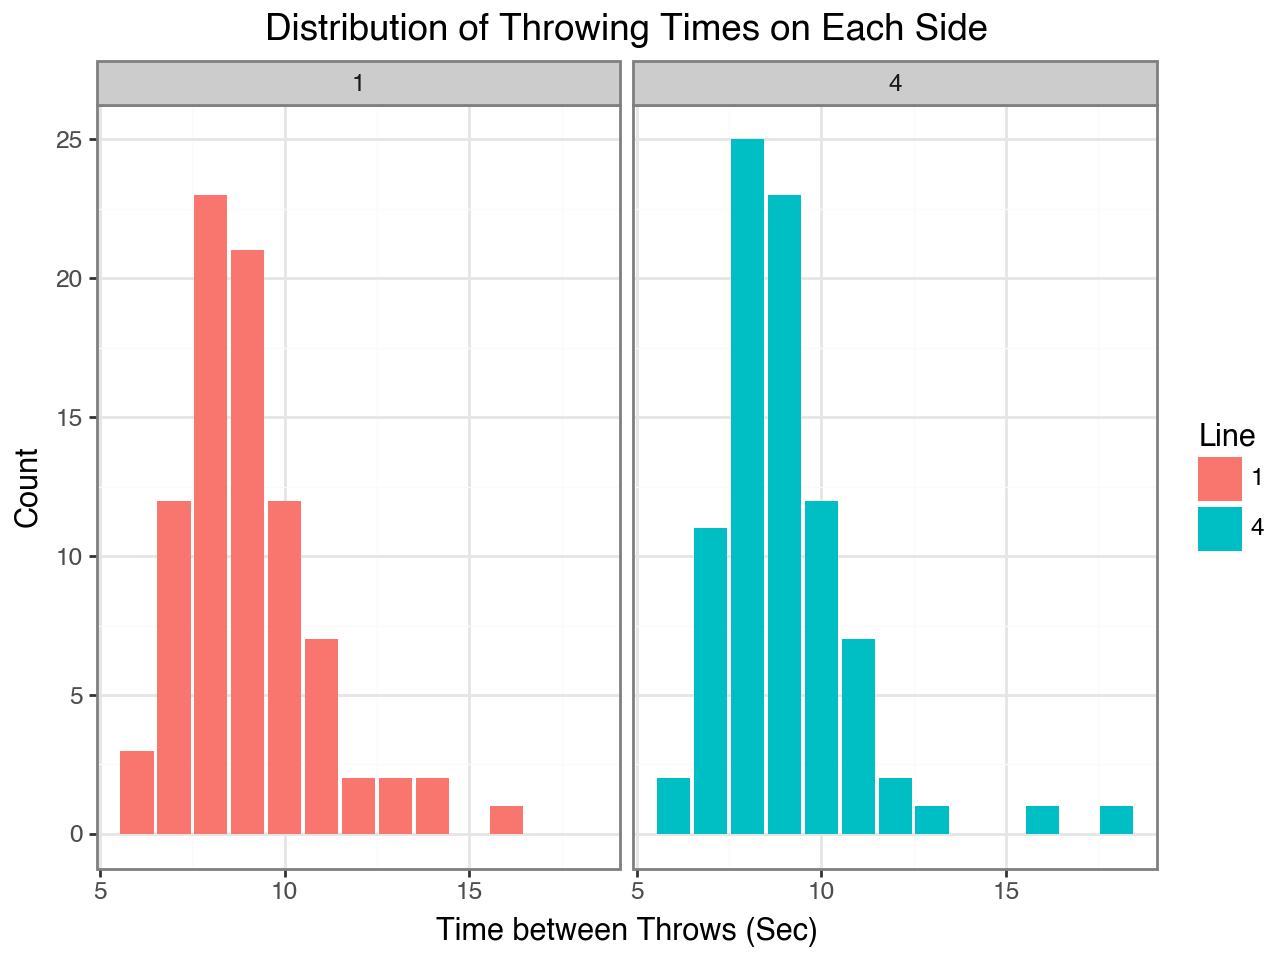

In [29]:
from plotnine import ggplot, aes, geom_point, geom_line, facet_wrap, labs, theme_bw, geom_bar, geom_col, scale_x_continuous, scale_y_continuous

(ggplot(df_dist, aes(x="Delay", y="Count", fill="factor(Line)")) +
 geom_col(position="dodge") +
 facet_wrap("Line") +
 theme_bw() +
 labs(x="Time between Throws (Sec)", y="Count", fill="Line", title="Distribution of Throwing Times on Each Side")
 )

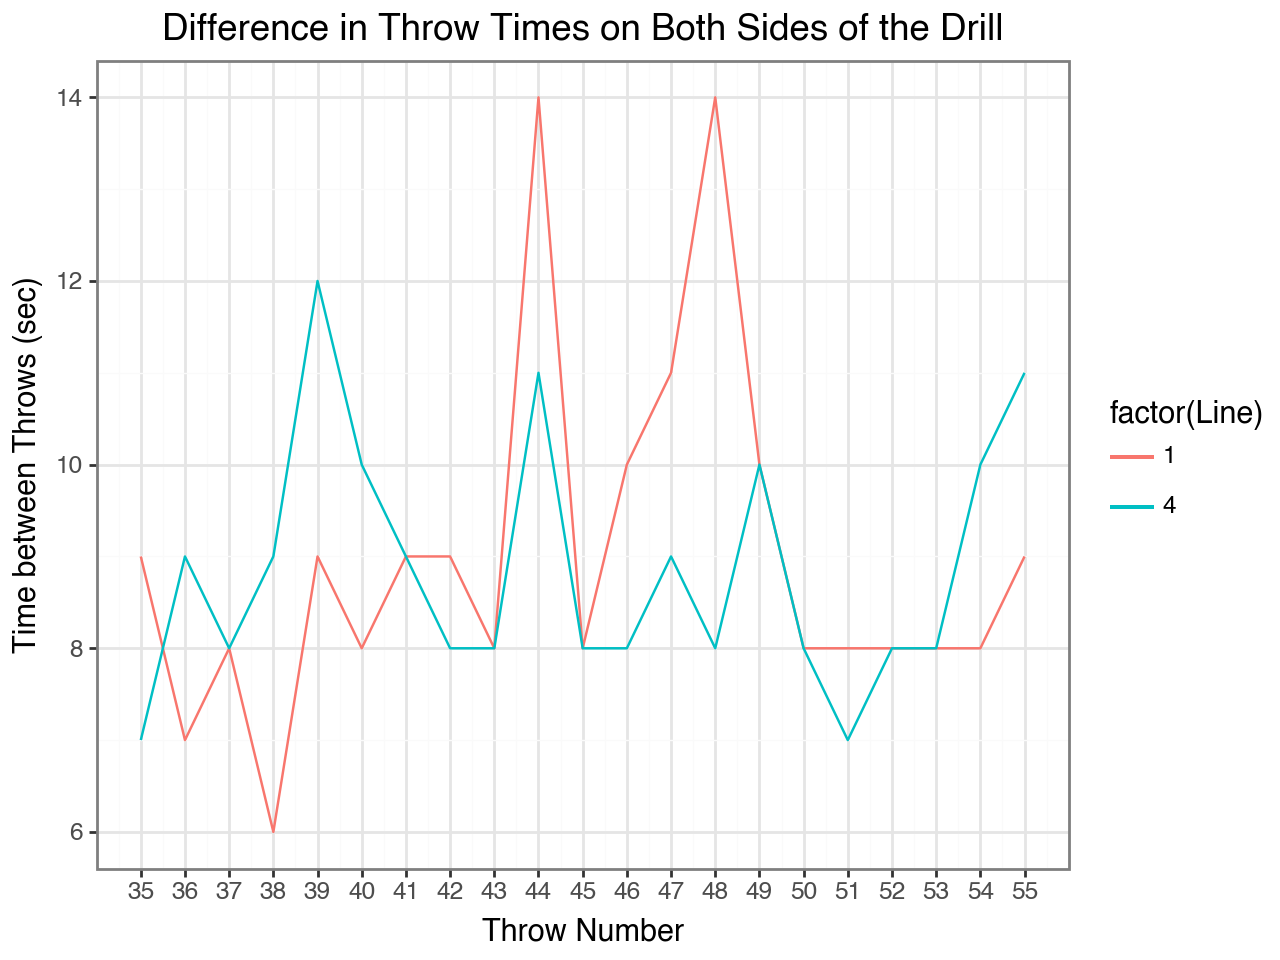

In [30]:
from plotnine import scale_x_continuous

(
    ggplot(df_throwtime, aes(x="id", y="Seconds", color="factor(Line)"))
    + geom_line()
    + theme_bw()
    + scale_x_continuous(breaks=np.arange(35, 56, 1))
    + labs(
        x="Throw Number",
        y="Time between Throws (sec)",
        fill="Line",
        title="Difference in Throw Times on Both Sides of the Drill",
    )
)

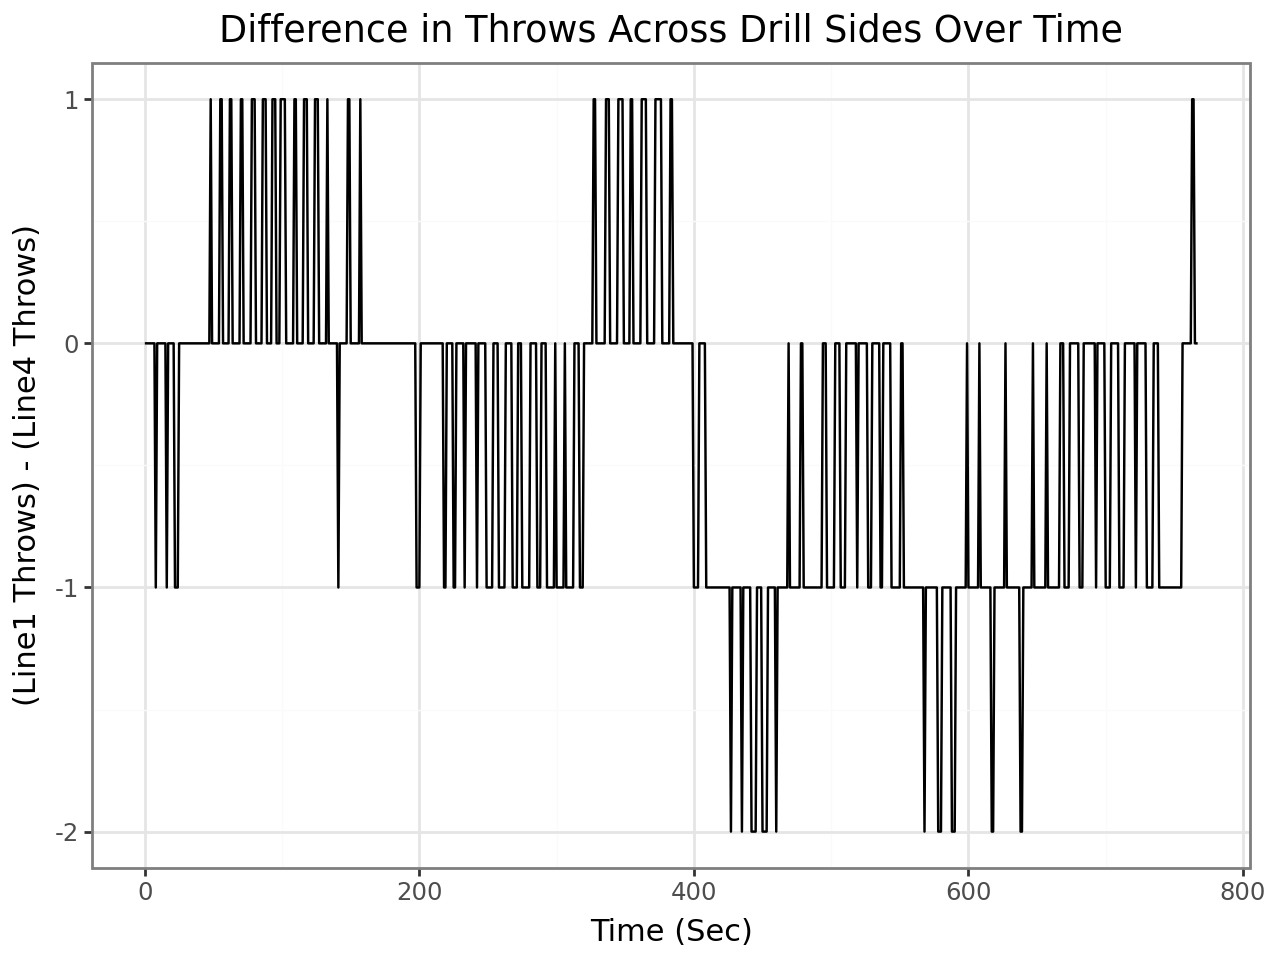

In [ ]:
(ggplot(df_diff, aes(x="Seconds", y="Throw_Dif")) +
 geom_line() +
 #facet_wrap("factor(Line)") +
 theme_bw() +
 labs(x="Time (Sec)", y="(Line1 Throws) - (Line4 Throws)", color="Line", title=f"Difference in Throws Across Drill Sides Over Time")
 )

# This but not net

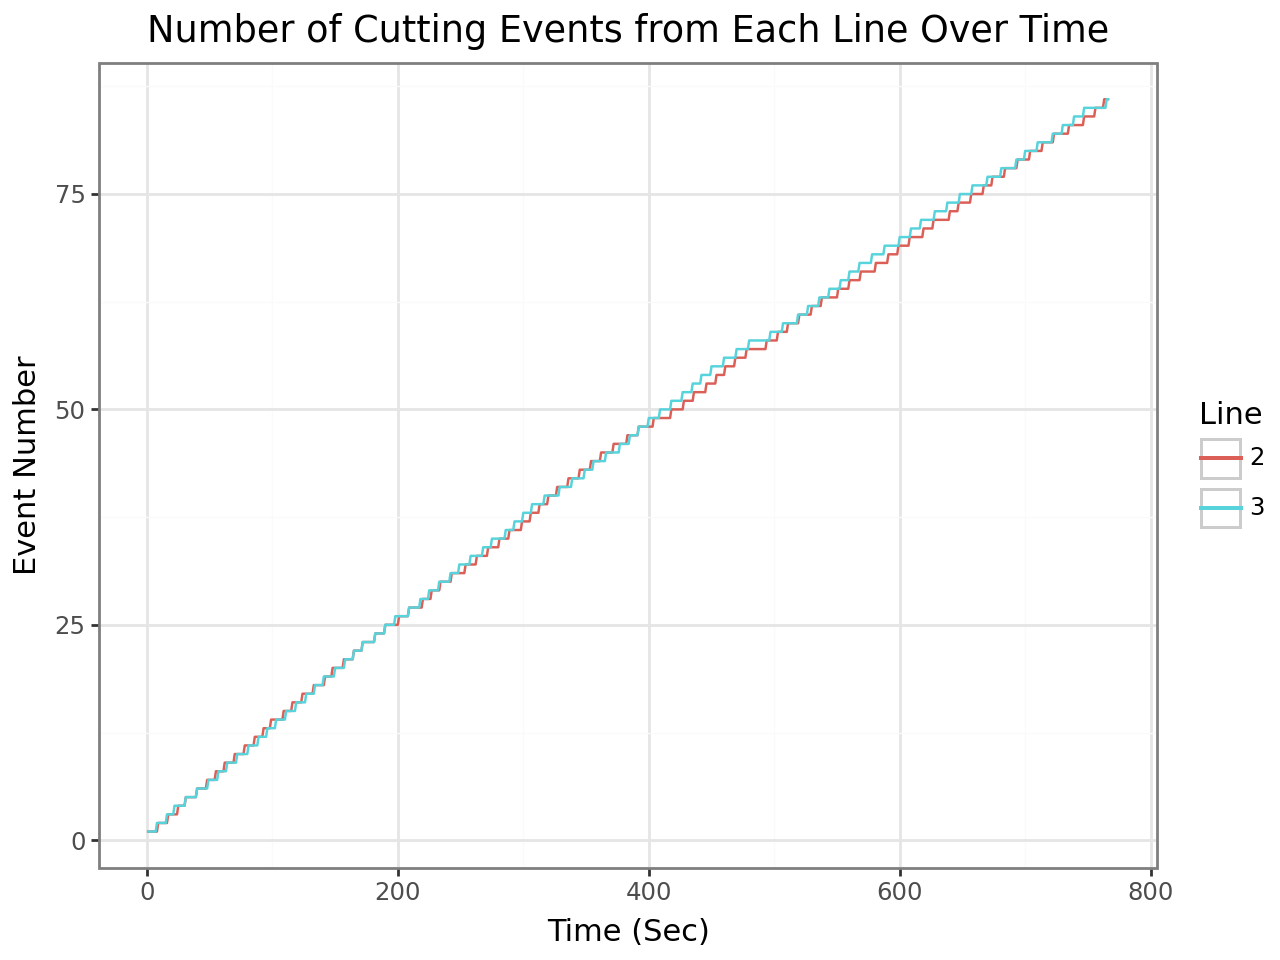

In [ ]:
from plotnine import geom_vline
(ggplot(df_time, aes(x="Seconds", y="CUM@", color="factor(Line)")) +
 geom_line() +
 #facet_wrap("factor(Line)") +
 labs(x="Time (Sec)", y="Event Number", color="Line", title=f"Number of Cutting Events from Each Line Over Time") +
 #scale_y_continuous(breaks=range(100)) +
  theme_bw()

 )

# Kinda looks like sponteneous events!!
# Could even go back to the footage to check what's happening

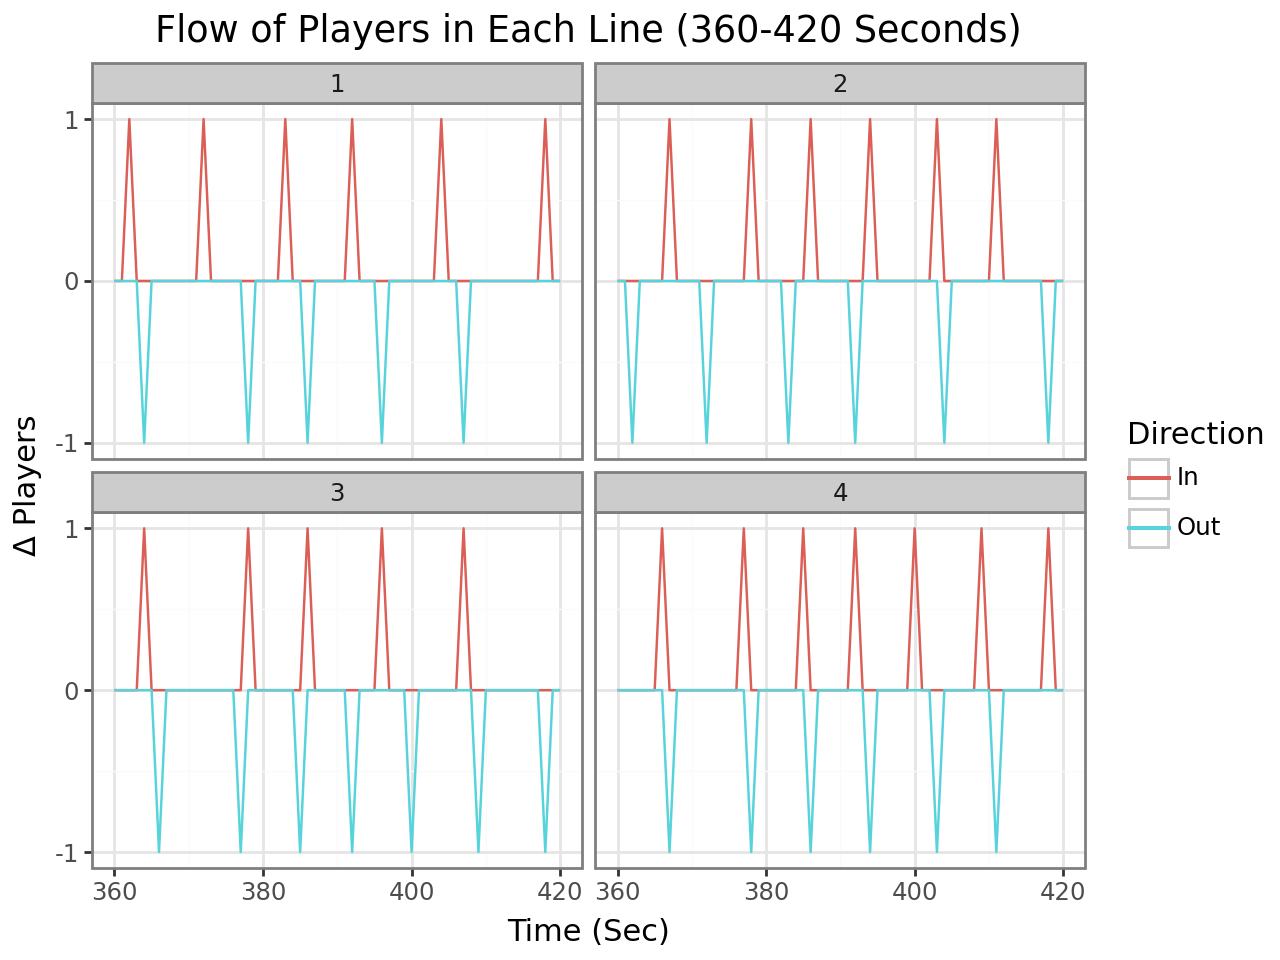

In [ ]:
(ggplot(df_flow, aes(x="Seconds", y="Quantity", color="factor(Direction)")) +
 geom_line() +
 facet_wrap("Line") +
 scale_y_continuous(breaks=[-1, 0, 1]) +
 theme_bw() +
 labs(x="Time (Sec)", y="\u0394 Players", color="Direction", title=f"Flow of Players in Each Line (360-420 Seconds)")
 )

In [ ]:

(ggplot(df_low, aes(x="Seconds", y="Quantity", color="factor(Direction)")) +
 geom_line() +
 facet_wrap("Line") +
 theme_bw() +
 labs(x="Time (Sec)", y="\u0394 Players", color="Direction", title=f"Flow of Players in Each Line Over Time (Zoomed, Filter={filter}sec)")
 )

In [ ]:

(ggplot(df_nlow, aes(x="Seconds", y="Net_Filter", color="factor(Line)")) +
 geom_line() +
 facet_wrap("Line") +
 theme_bw() +
 labs(x="Time (Sec)", y="\u0394 Players", color="Line", title=f"Flow of Players in Each Line Over Time (Filter={filter}sec)")
 )

In [ ]:


(ggplot(df_stock, aes(x="Seconds", y="S", color="factor(Line)")) +
 geom_line() +
 geom_point() +
 facet_wrap("Line") +
 labs(x="Time (sec)", y="Players", color="Line", title="Distribution of Players over time in the 4-Line Drill") +
 theme_bw()
 )

In [ ]:


(ggplot(df_szoom, aes(x="Seconds", y="S", color="factor(Line)")) +
 geom_line() +
 geom_point() +
 facet_wrap("Line") +
 labs(x="Time (sec)", y="Players", color="Line", title="Distribution of Players over time in the 4-Line Drill (Zoomed in)") +
 theme_bw()
 )